# Generating Mosaics

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from torch.utils.data import DataLoader
import torch

from tqdm import tqdm
import pandas as pd

pd.set_option("display.max_colwidth", None)


## Get Data from Margherita

In [4]:
bch_path = Path('/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita')
bch_info_path = bch_path / 'marcus_info.csv'

Download the CSV and split / relabel things

In [5]:
bch_df = pd.read_csv(bch_info_path)

# 1. Replace beginning path of data locations
bch_df['path'] = str(bch_path) + bch_df['Data Location'].str.split('mnt1').str[1]
bch_df = bch_df.drop(columns = 'Data Location')

# 2. Get the person
bch_df["person"] = bch_df["path"].str.extract(r"(?:processed|failed)/(.*?)/raw/")

# 3. Get the mask location 
bch_df["mask_path"] = (
    bch_df['path'].str.replace("/raw/", "/masks/", regex=False)
    .str.replace(r"\.nii$", "_mask.nii", regex=True)
)

# 4. Add a flag for dataset
bch_df['dataset'] = 'BCH'

bch_df.head(5)

,Brain Type,path,person,mask_path,dataset
0,axi,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/raw/00004-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_4.nii,MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/masks/00004-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_4_mask.nii,BCH
1,sag,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/raw/00005-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_5.nii,MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/masks/00005-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_5_mask.nii,BCH
2,cor,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/raw/00006-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_6.nii,MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/masks/00006-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_6_mask.nii,BCH
3,axi,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/raw/00007-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_7.nii,MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/masks/00007-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_7_mask.nii,BCH
4,sag,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/raw/00008-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_8.nii,MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007,/data/vision/polina/users/mfirenze/Data_sharing_MIT_Margherita/processed/MAP-B510/MR-EI_Fetal_Neuro-26241177-20211007/masks/00008-T2_FETAL_BRAIN_T2_FETAL_BRAIN_20211007180316_8_mask.nii,BCH


# 

In [6]:
bch_df.count()

Brain Type    410
path          410
person        410
mask_path     410
dataset       410
dtype: int64

## Get Data from Ramya

In [7]:
ramya_path = Path('/data/vision/polina/users/marcusbl/data')

In [8]:
rows = []

for person_dir in ramya_path.iterdir():
    if not person_dir.is_dir():
        continue

    for stack_dir in person_dir.iterdir(): 
        if not stack_dir.is_dir():
            continue

        rows.append({
            'path': stack_dir / 'clean' / 'dicoms.npy',
            'Brain Type': None,
            'person': person_dir.stem,
            'dataset': "R",
            'mask_path': stack_dir / 'clean' / 'masks.npy'
        })

ramya_df = pd.DataFrame(rows)

In [9]:
ramya_df.head(5)

,path,Brain Type,person,dataset,mask_path
0,/data/vision/polina/users/marcusbl/data/anon-00067-2-11-2015/stack_1/clean/dicoms.npy,None,anon-00067-2-11-2015,R,/data/vision/polina/users/marcusbl/data/anon-00067-2-11-2015/stack_1/clean/masks.npy
1,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_8/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_8/clean/masks.npy
2,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_2/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_2/clean/masks.npy
3,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_5/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_5/clean/masks.npy
4,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_1/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_1/clean/masks.npy


# Merge the DataFrames!!

In [10]:
assert sorted(ramya_df.columns) == sorted(bch_df.columns)
df = pd.concat([ramya_df, bch_df])
df = df.reset_index(drop=True)

In [11]:
df['person'].nunique()

98

We add unique ids for each person -- currently 99 of them!

In [12]:
all_people = set(df["person"])
person_to_id = {p:i for i,p in enumerate(all_people)}
id_to_person = {i:p for i,p in enumerate(all_people)}
df['person_id'] = df["person"].map(person_to_id).astype(int)

assert df['person_id'].max() == df['person'].nunique() - 1

In [13]:
df.head(5)

,path,Brain Type,person,dataset,mask_path,person_id
0,/data/vision/polina/users/marcusbl/data/anon-00067-2-11-2015/stack_1/clean/dicoms.npy,None,anon-00067-2-11-2015,R,/data/vision/polina/users/marcusbl/data/anon-00067-2-11-2015/stack_1/clean/masks.npy,42
1,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_8/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_8/clean/masks.npy,77
2,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_2/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_2/clean/masks.npy,77
3,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_5/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_5/clean/masks.npy,77
4,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_1/clean/dicoms.npy,None,anon-00044-4-21-2017,R,/data/vision/polina/users/marcusbl/data/anon-00044-4-21-2017/stack_1/clean/masks.npy,77


## Displaying the Mosaics

In [14]:
import nibabel as nib
from matplotlib.backends.backend_pdf import PdfPages


In [15]:
def minmax(img: np.ndarray, mask: np.ndarray, perc: float = 0.01):
    """
    Percentile-based min–max normalization using a mask.

    img:  (H, W) or (C, H, W)
    mask: (H, W) boolean or 0/1
    perc: lower/upper percentile to clip (e.g., 0.01 → 1%–99%)
    """

    values = img[mask]

    if values.size == 0:
        print('here')
        return np.zeros_like(img)

    img_min = np.quantile(values, perc)
    img_max = np.quantile(values, 1.0 - perc)

    if img_max <= img_min:
        return np.zeros_like(img)

    new_img = (img - img_min) / (img_max - img_min)
    return np.clip(new_img, 0, 1)


In [16]:
def display_mosaic(scan_path: Path, mask_path: Path, save_path: Path = None):
    """
    Will apply min-max normalization w perc = .01 wrt the mask,
    
    If mask is too small, it'll display it normally and flag it
    """
    # Download nifti data and mask data
    if scan_path.suffix == '.npy':
        nifti_data = np.load(scan_path)
    else:
        nifti_img = nib.load(scan_path)
        nifti_data = nifti_img.get_fdata()

    if mask_path.suffix == '.npy':
        mask_data = np.load(mask_path).astype(bool)
    else:
        mask_img = nib.load(mask_path)
        mask_data = mask_img.get_fdata().astype(bool)

    # Calculate the # of scans
    start, end = 100, 0
    for scan_num in range(nifti_data.shape[-1]):
        mask = mask_data[:, :, scan_num] 

        if mask.sum() > 0:
            start = min(start, scan_num)
            end = max(end, scan_num)

    all_scans = list(range(start, end + 1)) # [start, end] inclusive 
    num_scans = len(all_scans)

    # Create the Grid
    if num_scans == 0:
        print(f"No masks found for {scan_path}")
        fig, ax = plt.subplots()
        ax.axis('off')
        ax.set_title("NO DATA")
        return fig


    nrows = int(np.floor(np.sqrt(num_scans)))
    ncols = int(np.ceil(num_scans / nrows))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(2 * ncols, 2 * nrows)
    )

    # Ensure axes is always 2D
    axes = np.atleast_2d(axes)

    for i in range(nrows):
        for j in range(ncols):
            cnt = i * ncols + j

            # stop if at the end
            if cnt >= num_scans:
                axes[i,j].axis('off')
                continue
            
            scan_num = all_scans[cnt]

            mask = mask_data[:, :, scan_num].astype(bool)
            scan = nifti_data[:, :, scan_num]

            if mask.sum() > 30:
                img = minmax(scan, mask, perc = .01)
                axes[i,j].imshow(img, cmap='grey', vmin=0,vmax = 1)
            else:
                axes[i,j].imshow(scan, cmap ='grey')
                axes[i, j].text(
                    0.98, 0.98, "⚠",
                    transform=axes[i, j].transAxes,
                    ha="right",
                    va="top",
                    fontsize=14,
                    color="red",
                    weight="bold"
                )
            axes[i,j].text(
                0.02, 0.98, f'{scan_num}',
                transform=axes[i,j].transAxes,
                ha = "left",
                va = "top", 
                fontsize = 14,
                color='yellow',
                weight='bold'
            )

            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            axes[i, j].set_frame_on(False)

    # Tight layout to remove extra space
    plt.tight_layout()  # small padding between axes
    plt.subplots_adjust(wspace=0.05, hspace=0.05)  # minimal whitespace
    plt.close(fig)
    
    return fig


In [17]:
# all_rows = list(df.iterrows())
# print(len(all_rows))
# for i, row in tqdm(all_rows):
#     scan_path = Path(row['path'])
#     mask_path = Path(row['mask_path']) 

#     save_path = Path(f'/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/{i}.png')
#     if save_path.exists():
#         continue

#     if 'MAP-C425' in str(scan_path):
#         continue
#     display_mosaic(scan_path, mask_path, save_path)


Constructing the PDFs as follows:
1. Initial Map: Get map {person -> stacks}. Take 2 random stacks and put it into list A; put rest into list B. 
2. Redundancies: From list A, select 20-30 stacks and duplicate them in the list.
3. Put stacks into PDF (~50 stacks per PDF) 


Construct Excel Sheets:
1. One excel sheet for each PDF
2. Each column is a different stack #
3. Input stack_num into the column IF it's WRONG
4. If questionable, put a ? w/ the number

In [18]:
num_redundant = 30
num_stacks_per_pdf = 50

In [19]:
listA = []
listB = []

In [20]:
person_map = df.groupby(by='person_id')

for person_id, person_df in person_map:
    num_stacks = len(person_df)

    idxsA = np.random.choice(num_stacks, size=min(2, num_stacks), replace=False)
    idxsB = list(set(range(num_stacks)) - set(idxsA))

    # convert local idx -> global df index
    listA.extend(person_df.iloc[idxsA].index.tolist()) 
    listB.extend(person_df.iloc[idxsB].index.tolist())

In [21]:
# Test mutually exclusive decomposition
assert set(listA) & set(listB) == set()
assert set(listA) | set(listB) == set(range(len(df)))

add redundancies

In [22]:
np.random.shuffle(listA)
listA = listA + listA[:num_redundant]


Form the PDFs!

In [23]:
pdf_dir = Path('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics')

**This part was done using generate_mosaics.py instead b/c the stupid kernel kept crashing. PDFs are all uploaded and DF can be downloaded**

In [24]:
# pdf_counter = 1
# stack_counter = 1
# figs = []

# for idx in tqdm(listA + listB): # do listA before listB

#     df.loc[idx, 'pdf_num'] = pdf_counter
#     df.loc[idx, 'stack_num'] = stack_counter
    
#     scan_path = Path(df.loc[idx, 'path'])
#     mask_path = Path(df.loc[idx, 'mask_path'])
    
#     fig = display_mosaic(scan_path, mask_path, save_path = None)        
#     fig.text(
#         0.99, 0.01,               # normalized figure coords (0,0 bottom-left; 1,1 top-right)
#         f"Stack {stack_counter}",  
#         color='red',
#         fontsize=14,
#         weight='bold',
#         va='bottom',                  # vertical alignment
#         ha='right'                  # horizontal alignment
#     )

#     figs.append(fig)

#     stack_counter += 1
#     if stack_counter > num_stacks_per_pdf:
#         # Make the pdf
#         print(f"Starting PDF {pdf_counter}")
#         with PdfPages(pdf_dir / f"pdf_{pdf_counter}.pdf") as pdf:
#             for fig in figs:
#                 pdf.savefig(fig)
#                 plt.close(fig)
#         print(f"Finished PDF {pdf_counter}")

#         figs = []
#         pdf_counter += 1
#         stack_counter = 1

# # Assert that (pdf_num, stack_num) uniquely captures the entire dataframe
# assert len(set(zip(df['pdf_num'], df['stack_num']))) == len(df)

# Downloading Final DF from .py and creating excel sheets

In [33]:
df = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/outputs_mosaics/df.csv')

In [34]:
len(df) - df['mask_path'].nunique()

30

In [35]:
df['person_id'].nunique()

98

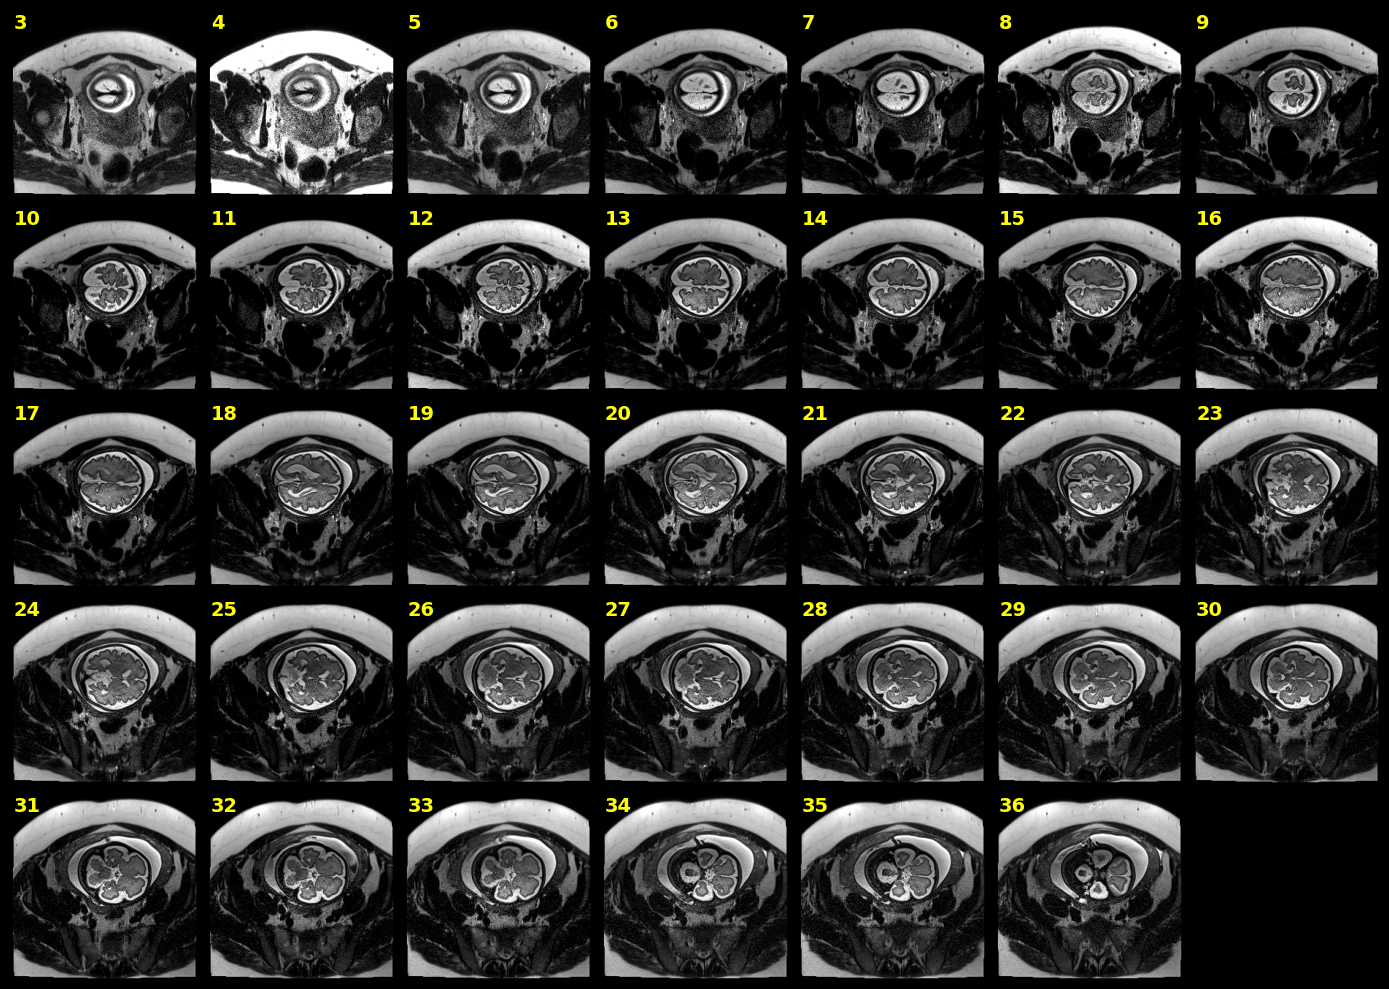

In [ ]:
display_mosaic(Path('/data/vision/polina/users/marcusbl/data/anon-00067-2-11-2015/stack_1/clean/dicoms.npy'),
               Path('/data/vision/polina/users/marcusbl/data/anon-00067-2-11-2015/stack_1/clean/masks.npy'),
               None)
# Look up on DF & compare this picture to the PDF-stack unm